# Visualizing categorical data

In the relational plot tutorial we saw how to use different visual representations to show the relationship between multiple variables in a dataset. In the examples, we focused on cases where the main relationship was between two numerical variables. If one of the main variables is “categorical” (divided into discrete groups) it may be helpful to use a more specialized approach to visualization.

In seaborn, there are several different ways to visualize a relationship involving categorical data. Similar to the relationship between relplot() and either scatterplot() or lineplot(), there are two ways to make these plots. There are a number of axes-level functions for plotting categorical data in different ways and a figure-level interface, catplot(), that gives unified higher-level access to them.

It’s helpful to think of the different categorical plot kinds as belonging to three different families, which we’ll discuss in detail below. They are:

Categorical scatterplots:

    stripplot() (with kind="strip"; the default)

    swarmplot() (with kind="swarm")

Categorical distribution plots:

    boxplot() (with kind="box")

    violinplot() (with kind="violin")

    boxenplot() (with kind="boxen")

Categorical estimate plots:
   
pointplot() (with kind="point")   

barplot() (with kind="bar   ")

countplot() (with kind="count")

These families represent the data using different levels of granularity. When deciding which to use, you’ll have to think about the question that you want to answer. The unified API makes it easy to switch between different kinds and see your data from several perspectives.

In this tutorial, we’ll mostly focus on the figure-level interface, catplot(). Remember that this function is a higher-level interface each of the functions above, so we’ll reference them when we show each kind of plot, keeping the more verbose kind-specific API documentation at hand.

seaborn.catplot(data=None, *, x=None, y=None, hue=None, row=None, col=None, kind='strip', estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, order=None, hue_order=None, row_order=None, col_order=None, col_wrap=None, height=5, aspect=1, log_scale=None, native_scale=False, formatter=None, orient=None, color=None, palette=None, hue_norm=None, legend='auto', legend_out=True, sharex=True, sharey=True, margin_titles=False, facet_kws=None, ci=<deprecated>, **kwargs)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Categorical scatterplots

The default representation of the data in catplot() uses a scatterplot. There are actually two different categorical scatter plots in seaborn. They take different approaches to resolving the main challenge in representing categorical data with a scatter plot, which is that all of the points belonging to one category would fall on the same position along the axis corresponding to the categorical variable. The approach used by stripplot(), which is the default “kind” in catplot() is to adjust the positions of points on the categorical axis with a small amount of random “jitter”:

In [6]:
tips = sns.load_dataset('tips')

In [7]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic',
 'anagrams',
 'anagrams',
 'anscombe',
 'anscombe',
 'attention',
 'attention',
 'brain_networks',
 'brain_networks',
 'car_crashes',
 'car_crashes',
 'diamonds',
 'diamonds',
 'dots',
 'dots',
 'dowjones',
 'dowjones',
 'exercise',
 'exercise',
 'flights',
 'flights',
 'fmri',
 'fmri',
 'geyser',
 'geyser',
 'glue',
 'glue',
 'healthexp',
 'healthexp',
 'iris',
 'iris',
 'mpg',
 'mpg',
 'penguins',
 'penguins',
 'planets',
 'planets',
 'seaice',
 'seaice',
 'taxis',
 'taxis',
 'tips',
 'tips',
 'titanic',
 'titanic',
 'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'plan

In [8]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


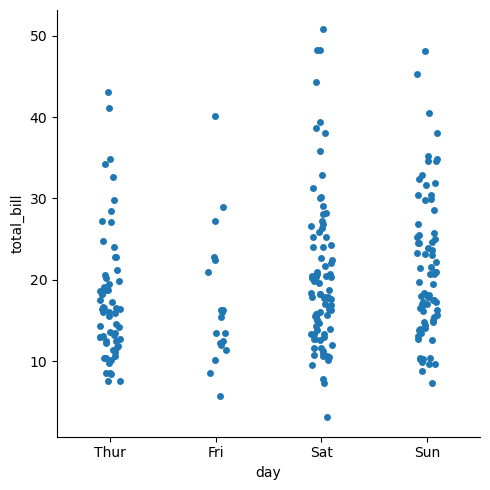

In [9]:
sns.catplot(data=tips, x = 'day', y='total_bill')

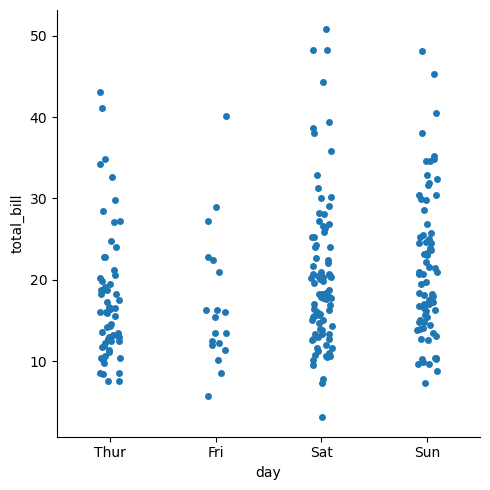

In [10]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind='strip')

The jitter parameter controls the magnitude of jitter or disables it altogether:

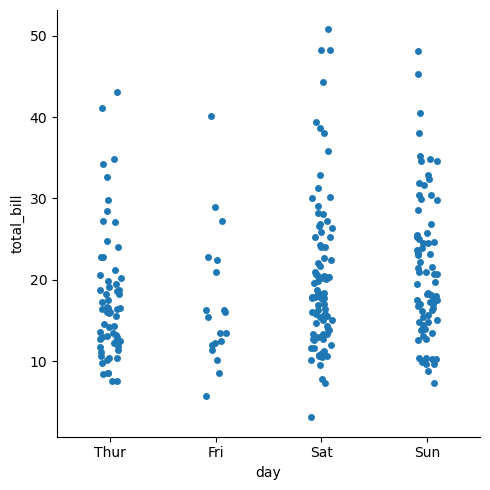

In [12]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind='strip', jitter=True)

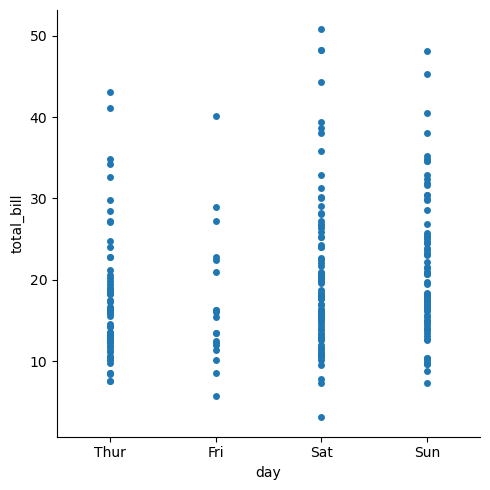

In [13]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind='strip', jitter=False)

The second approach adjusts the points along the categorical axis using an algorithm that prevents them from overlapping. It can give a better representation of the distribution of observations, although it only works well for relatively small datasets. This kind of plot is sometimes called a “beeswarm” and is drawn in seaborn by swarmplot(), which is activated by setting kind="swarm" in catplot():

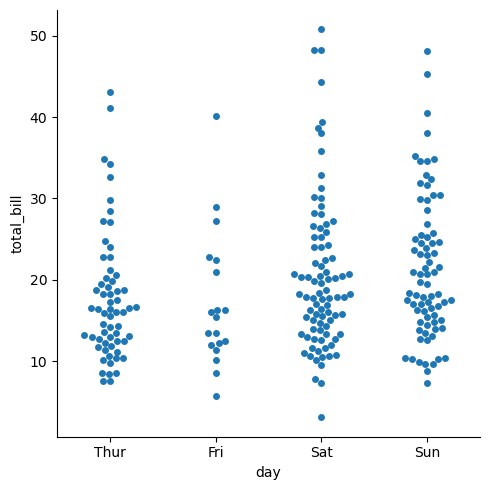

In [15]:
sns.catplot(data=tips, x='day', y = 'total_bill', kind='swarm')

Similar to the relational plots, it’s possible to add another dimension to a categorical plot by using a hue semantic. (The categorical plots do not currently support size or style semantics). Each different categorical plotting function handles the hue semantic differently. For the scatter plots, it is only necessary to change the color of the points:

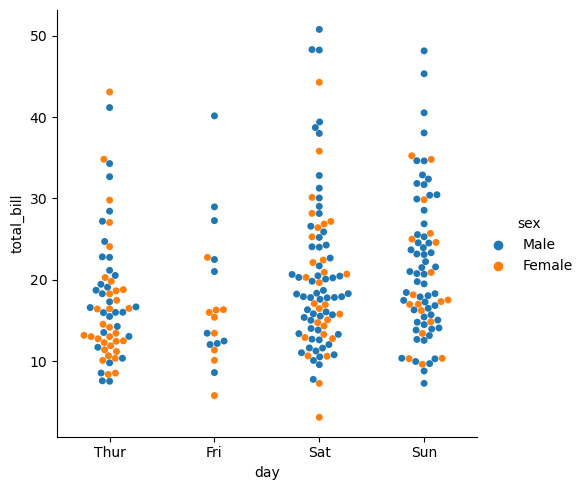

In [17]:
sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='swarm')

<Axes: xlabel='day', ylabel='total_bill'>

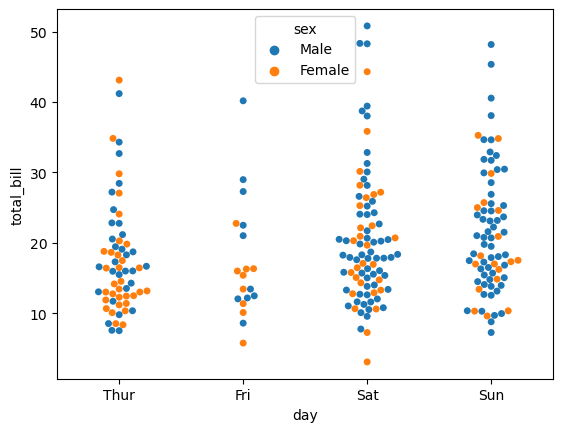

In [18]:
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex')

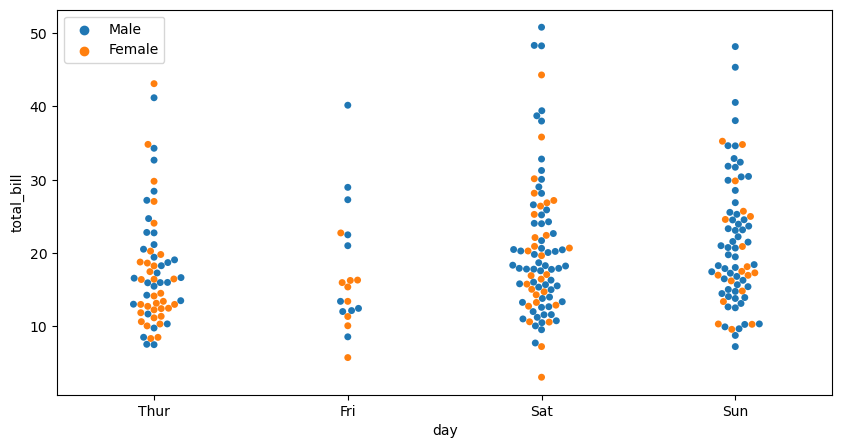

In [19]:
plt.figure(figsize=(10,5))
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex')
plt.legend(loc='upper left')

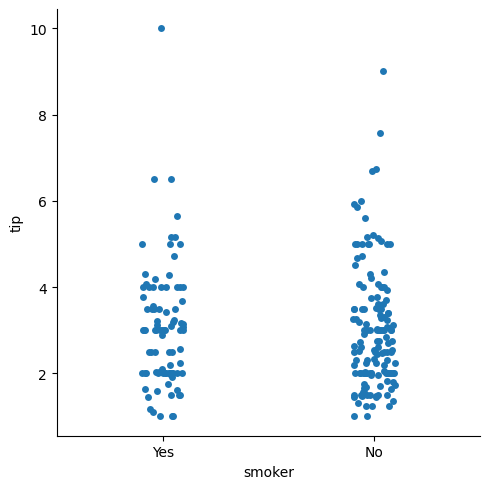

In [20]:
sns.catplot(data=tips, x = 'smoker', y='tip')

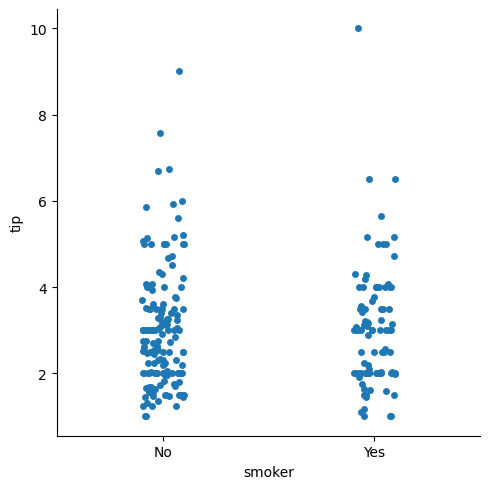

In [21]:
# category order
sns.catplot(data=tips, x = 'smoker', y='tip', order=['No','Yes'])

### Comparing distributions

As the size of the dataset grows, categorical scatter plots become limited in the information they can provide about the distribution of values within each category. When this happens, there are several approaches for summarizing the distributional information in ways that facilitate easy comparisons across the category levels.

### Boxplots

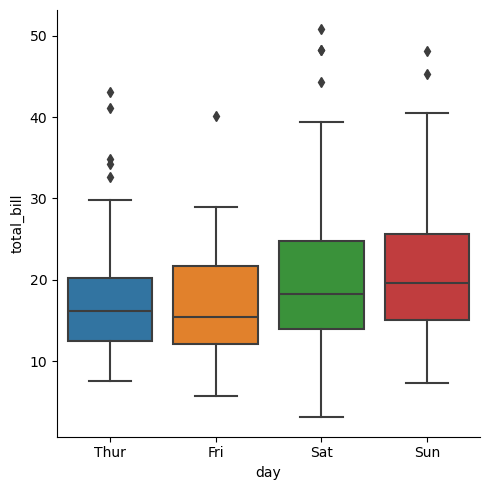

In [25]:
sns.catplot(data=tips, x='day', y='total_bill', kind='box')

When adding a hue semantic, the box for each level of the semantic variable is made narrower and shifted along the categorical axis:

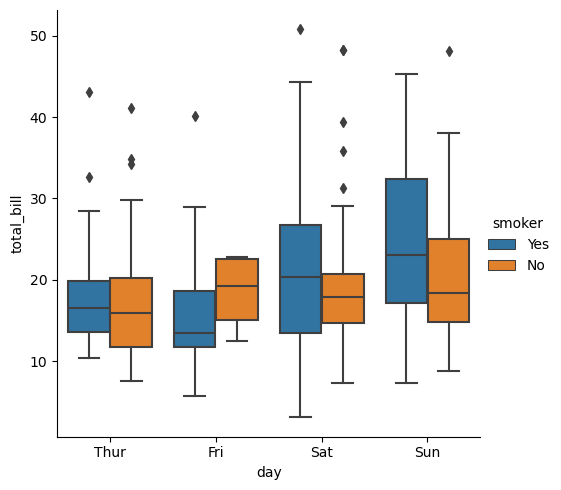

In [27]:
sns.catplot(data=tips, x='day', y='total_bill', hue='smoker', kind='box')

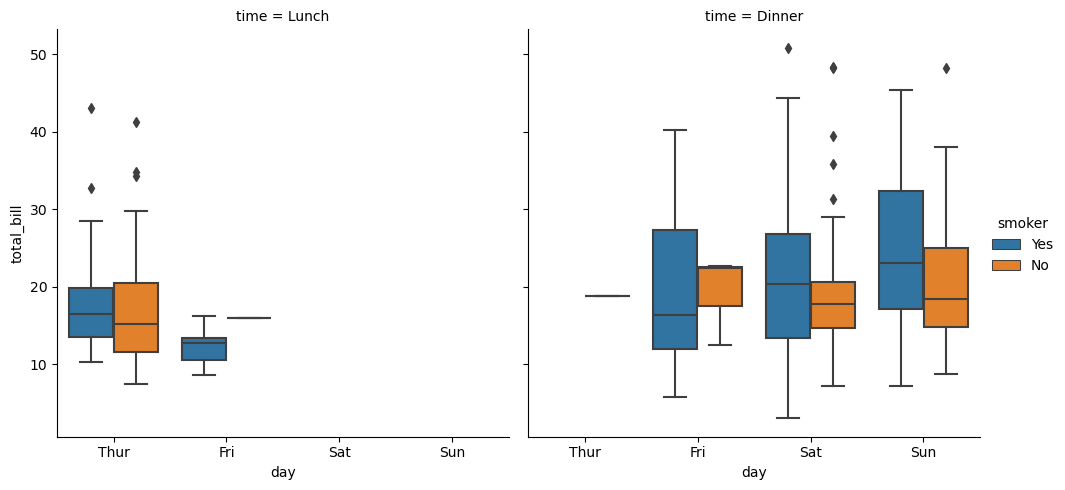

In [28]:
sns.catplot(data=tips, x='day', y='total_bill', hue='smoker', kind='box', col='time')

### Boxenplot

A related function, boxenplot(), draws a plot that is similar to a box plot but optimized for showing more information about the shape of the distribution. It is best suited for larger datasets:

In [31]:
diamonds = sns.load_dataset('diamonds')

In [32]:
diamonds.shape

(53940, 10)

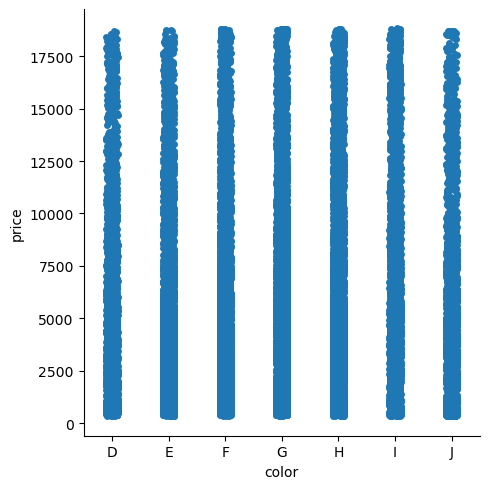

In [33]:
# for large dataset below method is not good
sns.catplot(data=diamonds, x='color', y='price')

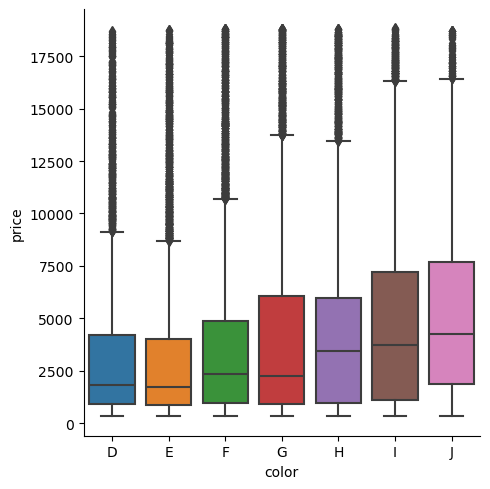

In [34]:
# for large dataset below method is also not good
sns.catplot(data=diamonds, x='color', y='price', kind='box')

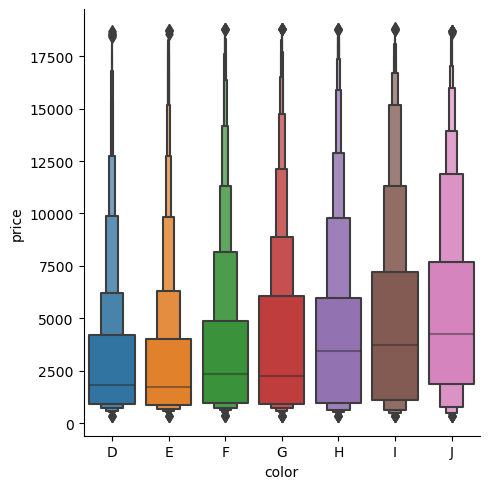

In [35]:
# for large dataset below method good
sns.catplot(data=diamonds, x='color', y='price', kind='boxen')

In [36]:
diamonds.groupby('color')['price'].max()

color
D    18693
E    18731
F    18791
G    18818
H    18803
I    18823
J    18710
Name: price, dtype: int64

### Violinplots

A different approach is a violinplot(), which combines a boxplot with the kernel density estimation procedure described in the distributions tutorial:

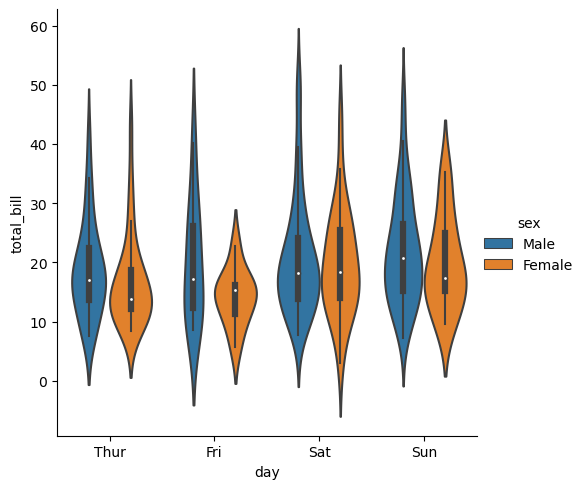

In [39]:
sns.catplot( data=tips, x="day", y="total_bill", hue="sex", kind="violin")

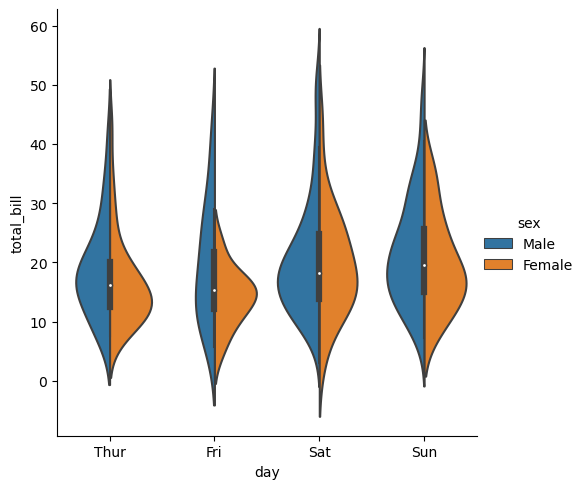

In [106]:
sns.catplot(data=tips,x='day',y='total_bill',hue='sex',kind='violin',split=True)

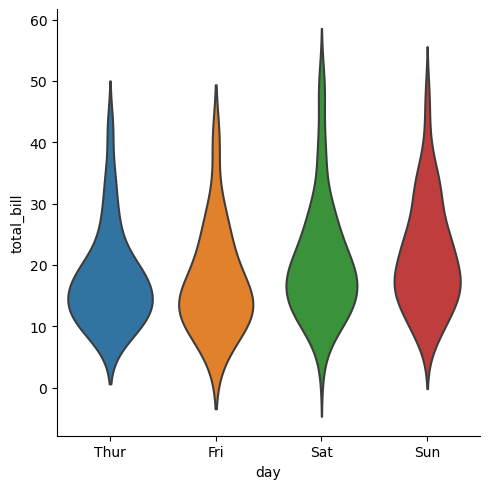

In [108]:
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',inner=None)

<Axes: xlabel='day', ylabel='total_bill'>

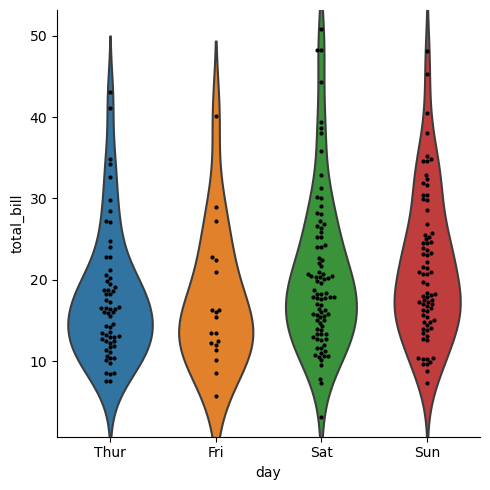

In [130]:
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',inner=None)
sns.swarmplot(data=tips,x='day',y='total_bill',color='black',size=3)

(-10.0, 60.0)

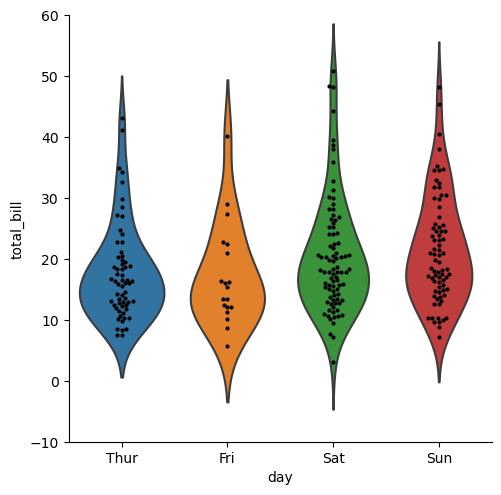

In [138]:
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',inner=None)
sns.swarmplot(data=tips,x='day',y='total_bill',color='black',size=3)
plt.ylim(-10,60)

### Salaries.csv dataset

In [41]:
df = pd.read_csv('Salaries.csv')

In [42]:
df.shape

(78, 6)

In [43]:
df.head()

,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800


<Axes: xlabel='discipline', ylabel='salary'>

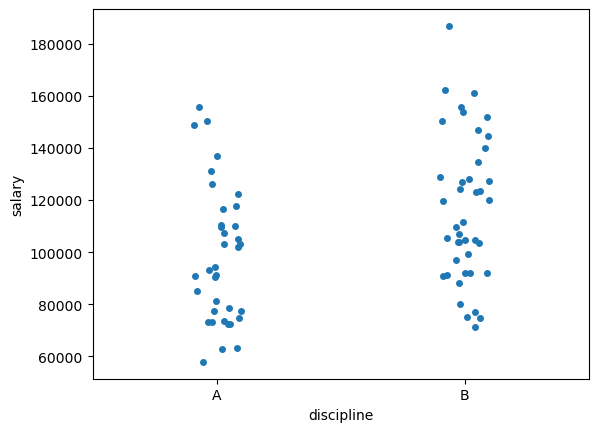

In [44]:
# stripplot over categories
sns.stripplot(x='discipline', y = 'salary', data=df, order=['A','B'])

<Axes: xlabel='salary', ylabel='discipline'>

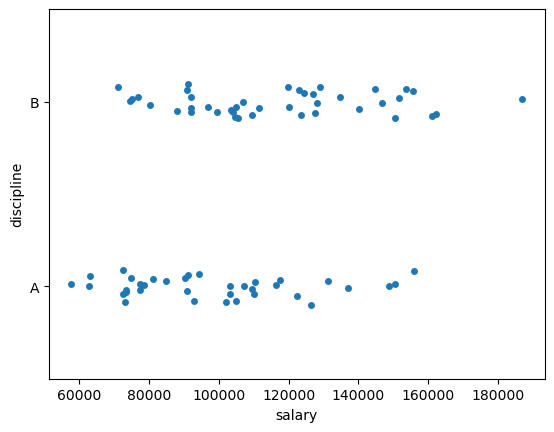

In [45]:
# Stripplot over categories Horizontal
sns.stripplot( x= 'salary', y = 'discipline',data=df, jitter=True)

<Axes: xlabel='rank', ylabel='salary'>

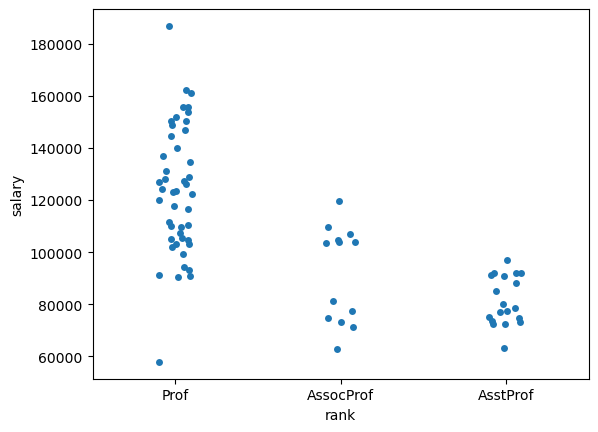

In [46]:
# Stripplot over categories
sns.stripplot( x = df['rank'], y= df['salary'], 
data=df, jitter=True)

<Axes: xlabel='sex', ylabel='salary'>

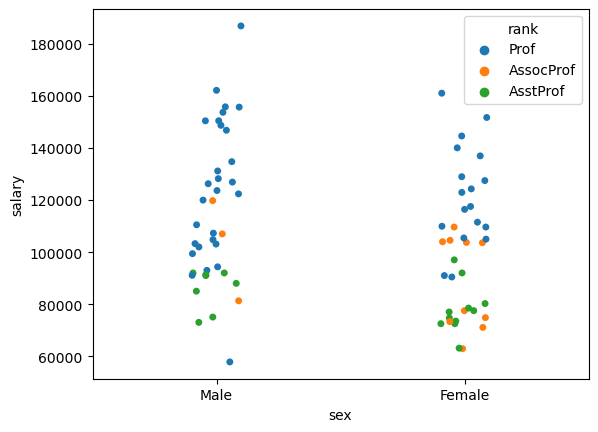

In [47]:
# Add hue to the graph
 # Stripplot over categories
sns.stripplot( x ='sex', y= 'salary', hue='rank', data=df, jitter=True )

<Axes: xlabel='salary', ylabel='sex'>

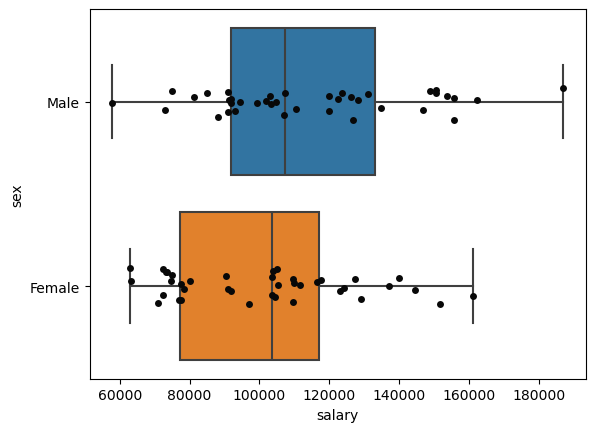

In [48]:
 #Draw data on top of boxplot
 sns.boxplot(x = 'salary', y ='sex', data=df)
 sns.stripplot(x = 'salary', y ='sex', data=df, jitter=True, color='0.03')

<Axes: xlabel='salary', ylabel='sex'>

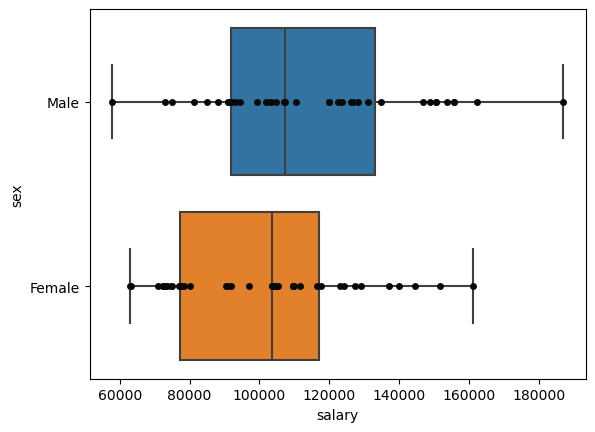

In [49]:
 #Draw data on top of boxplot
 sns.boxplot(x = 'salary', y ='sex', data=df)
 sns.stripplot(x = 'salary', y ='sex', data=df, jitter=False, color='0.03')

<Axes: xlabel='salary'>

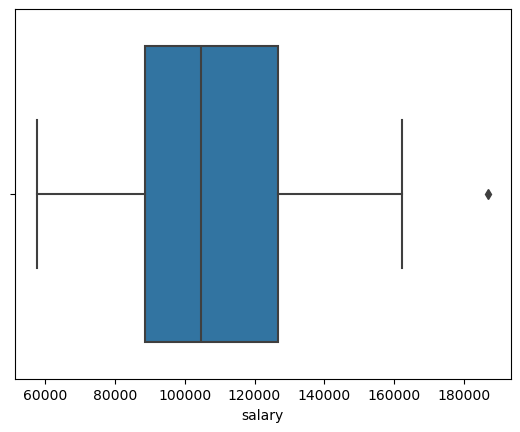

In [50]:
# box plot salaries
sns.boxplot(x = df['salary'])

<Axes: xlabel='rank', ylabel='salary'>

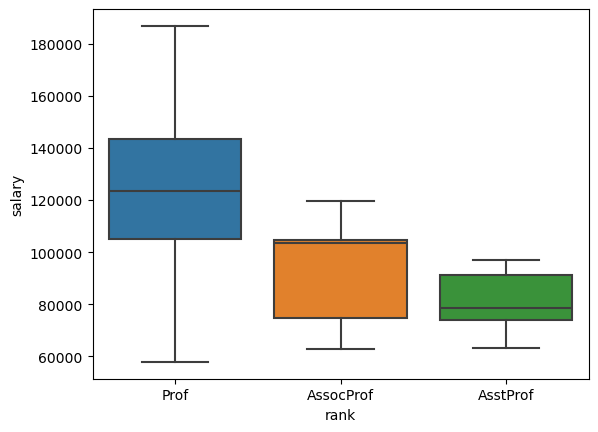

In [51]:
# box plot per rank
sns.boxplot(x = 'rank', y = 'salary', data=df)

<Axes: xlabel='rank', ylabel='salary'>

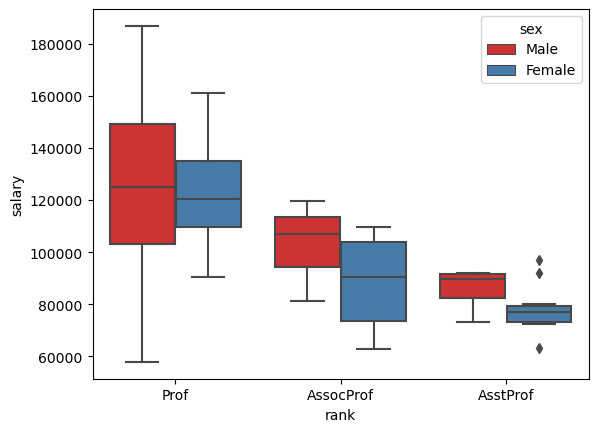

In [52]:
# box plot per rank
sns.boxplot(x = 'rank', y = 'salary', hue='sex', data=df, 
palette='Set1')

<Axes: xlabel='rank', ylabel='salary'>

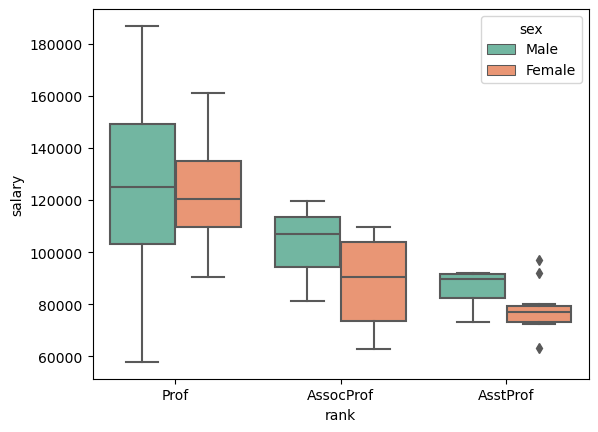

In [53]:
# box plot per rank
sns.boxplot(x = 'rank', y = 'salary', hue='sex', data=df, 
palette='Set2')

<Axes: xlabel='rank', ylabel='salary'>

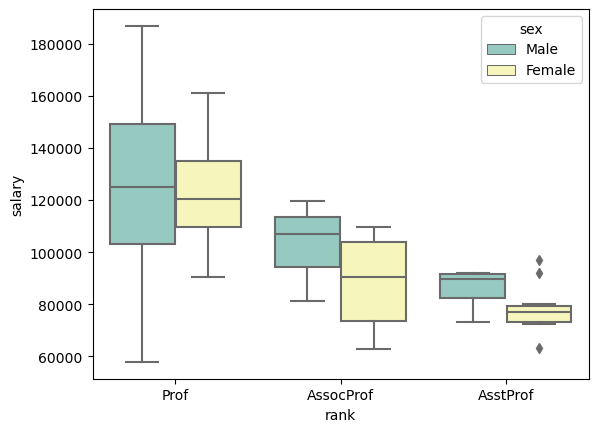

In [54]:
# box plot per rank
sns.boxplot(x = 'rank', y = 'salary', hue='sex', data=df, 
palette='Set3')

<Axes: xlabel='rank', ylabel='salary'>

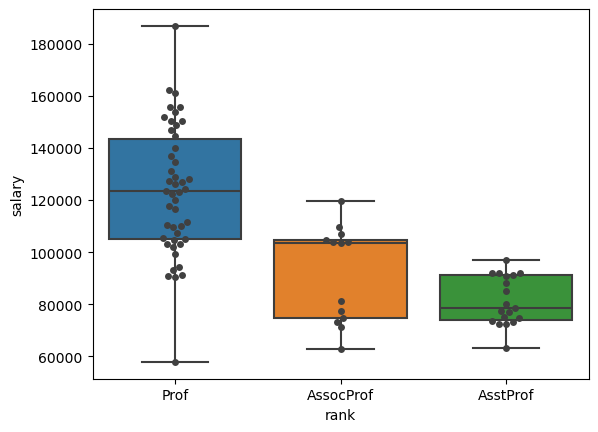

In [55]:
# box plot per rank
sns.boxplot(x = 'rank', y = 'salary', data=df)
sns.swarmplot(x = 'rank', y = 'salary', data=df, 
color='0.25')

<Axes: xlabel='sex', ylabel='salary'>

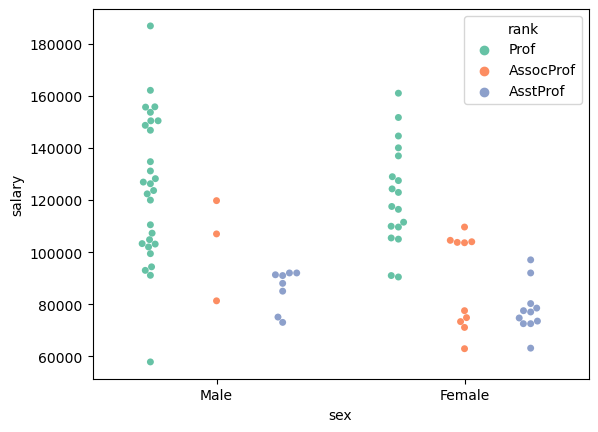

In [56]:
 # swarmplot
sns.swarmplot( x ='sex', y= 'salary', hue='rank', data=df, 
palette="Set2", dodge=True)

<Axes: xlabel='sex', ylabel='salary'>

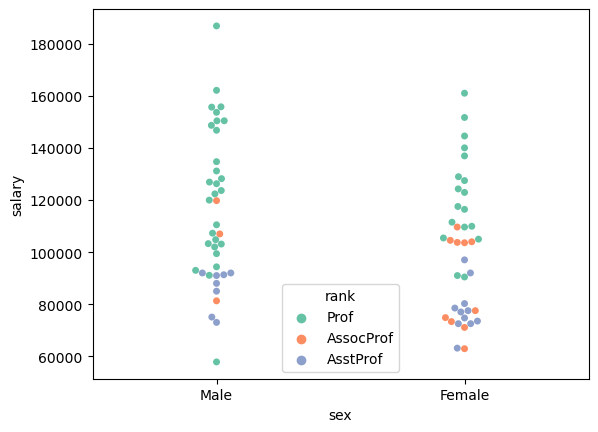

In [57]:
sns.swarmplot( x ='sex', y= 'salary', hue='rank', data=df, 
palette="Set2", dodge=False)

### Example

In [4]:
df = sns.load_dataset('titanic')

In [5]:
df.shape

(891, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


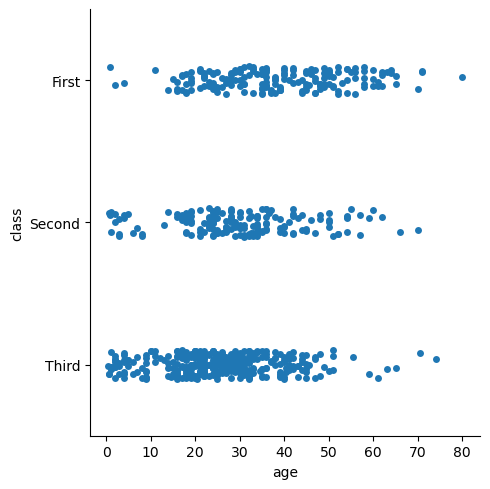

In [10]:
sns.catplot(data=df,x='age',y='class')

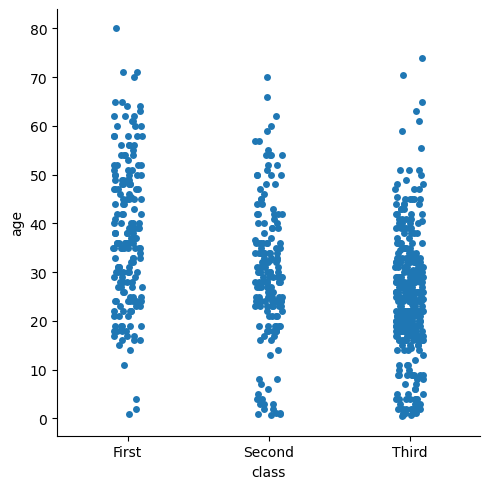

In [12]:
sns.catplot(data=df,y='age',x='class')

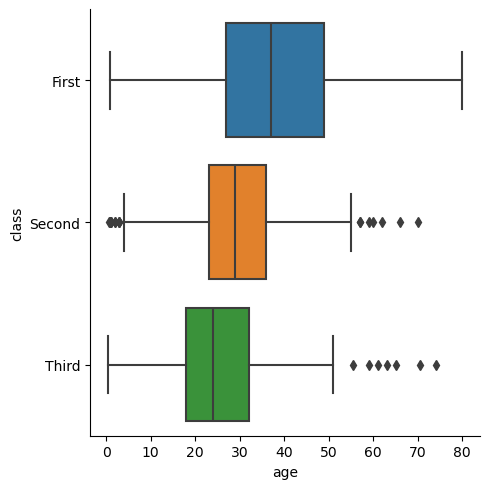

In [14]:
sns.catplot(data=df,x='age',y='class',kind='box')

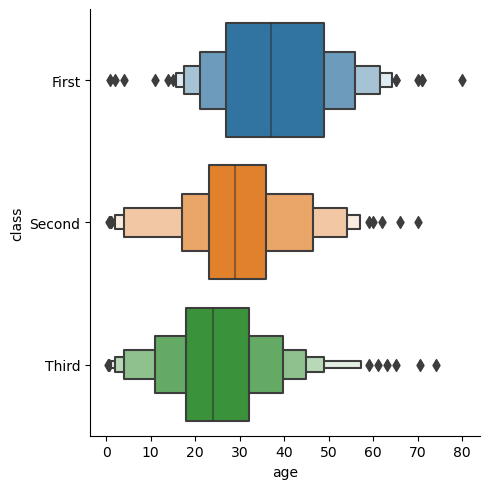

In [16]:
sns.catplot(data=df,x='age',y='class',kind='boxen')

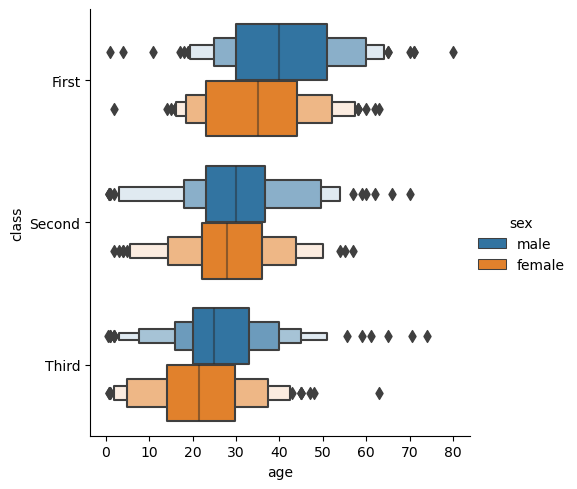

In [18]:
sns.catplot(data=df,x='age',y='class',hue='sex',kind='boxen')

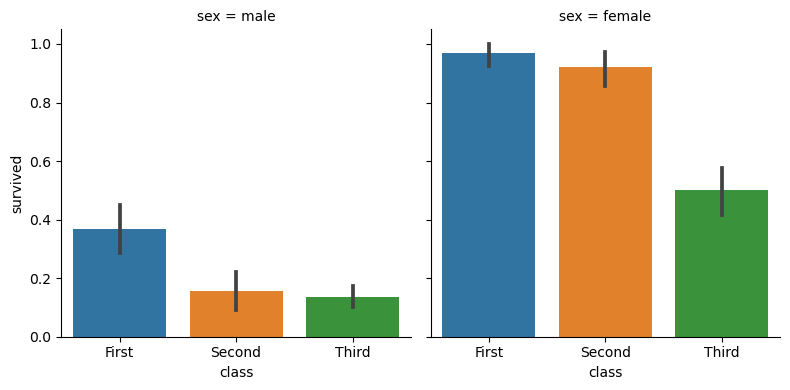

In [34]:
sns.catplot(
    data=df,x='class',y='survived',kind='bar',col='sex',height=4)

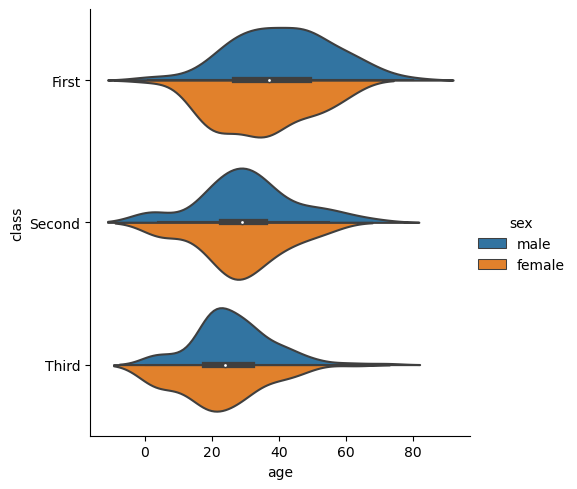

In [54]:
sns.catplot(
    data=df, x='age',y='class',kind='violin',hue='sex',split=True,bw_adjust=.5)

<Axes: xlabel='age', ylabel='class'>

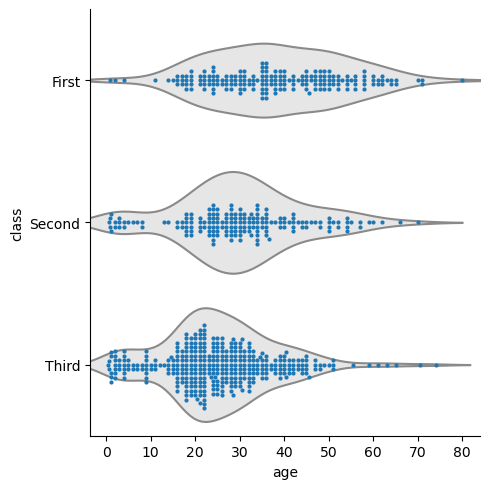

In [68]:
sns.catplot(data=df, x='age',y='class',kind='violin',inner=None,color='.9')
sns.swarmplot(data=df, x='age',y='class',size=3)

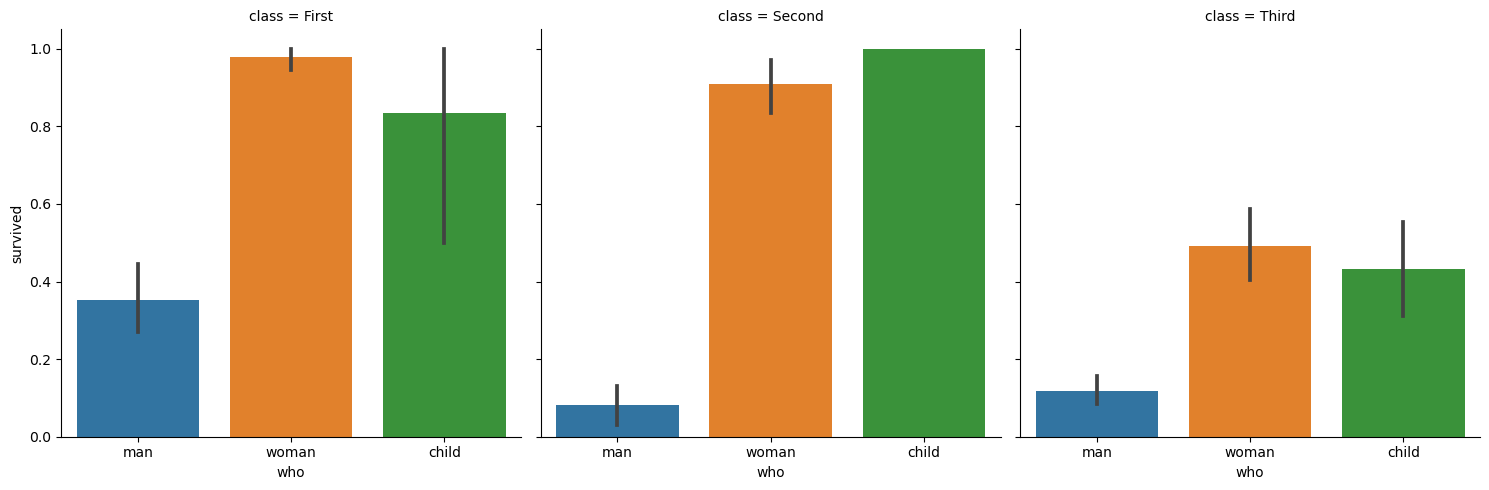

In [70]:
g = sns.catplot(data=df, x='who',y='survived',col='class',kind='bar')

### countplot()

In [131]:
titanic = sns.load_dataset('titanic')

In [133]:
titanic['class'].value_counts()

Third     491
First     216
Second    184
Name: class, dtype: int64

In [135]:
len(titanic)

891

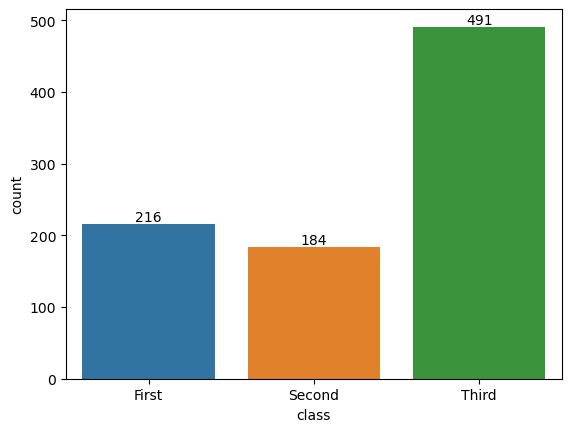

In [137]:
ax = sns.countplot(data = titanic,x='class')

for i in ax.containers:
    ax.bar_label(i,)

In [139]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [141]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


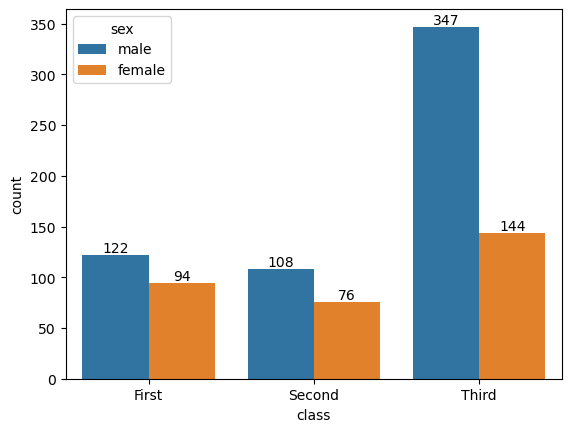

In [143]:
ax = sns.countplot(titanic,x='class',hue='sex')
for i in ax.containers:
    ax.bar_label(i,)

In seaborn barplot with bar, values can be plotted using sns.barplot() function and the sub-method containers returned by sns.barplot(). Import pandas, numpy, and seaborn packages. Read the dataset using the pandas read_csv function. Now, create a barplot between two columns, here, let’s choose the x-axis is time and the y-axis as a tip. This will return a conventional bar plot. This plot object is stored in a variable. The plot object has a method called containers that would list the properties of each bar. Iterate through the list items of the container object and pass each item to the bar_label function. This will extract and display the bar value in the bar plot.

In [146]:
data = sns.load_dataset('tips')

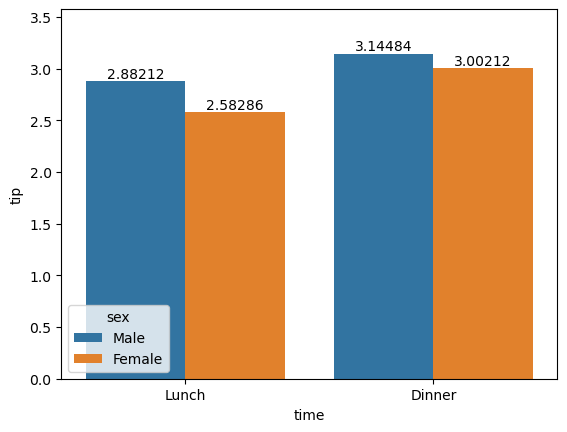

In [152]:
ax = sns.barplot(x='time', y='tip',
                 hue='sex', data=data,
                 errwidth=0)
for i in ax.containers:
    ax.bar_label(i,)

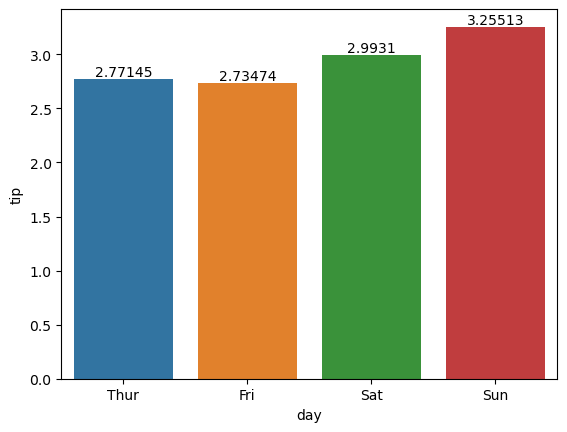

In [196]:
ax = sns.barplot(x='day',y='tip',data=data,errorbar=None)

for i in ax.containers:
    ax.bar_label(i,)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13168\1178837994.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  groupedvalue = data.groupby('day').sum().reset_index()


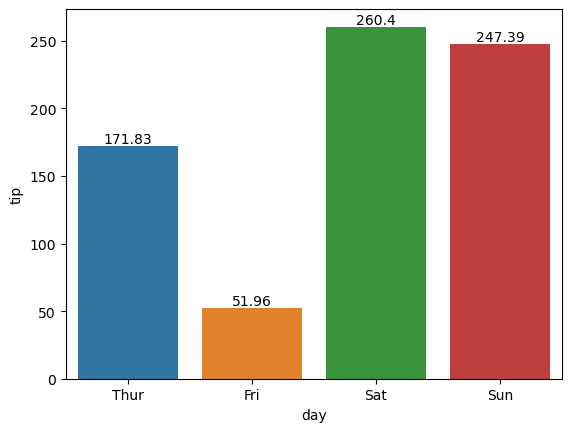

In [194]:
# group the multi level categorical variables
# and reset_ the index to flatten the index
groupedvalue = data.groupby('day').sum().reset_index()

# use sns barplot to plot bar plot
# between days and tip value
ax = sns.barplot(x='day',y='tip',data=groupedvalue,errorbar=None)


# now simply assign the bar values to
# each bar by passing containers method
# to bar_label function
for i in ax.containers:
    ax.bar_label(i,)

In [188]:
groupedvalue

,total_bill,tip,size
day,,,
Thur,1096.33,171.83,152
Fri,325.88,51.96,40
Sat,1778.40,260.40,219
Sun,1627.16,247.39,216


In [184]:
data[data['day']=='Fri'].describe()

,total_bill,tip,size
count,19.000000,19.000000,19.000000
mean,17.151579,2.734737,2.105263
std,8.302660,1.019577,0.567131
min,5.750000,1.000000,1.000000
25%,12.095000,1.960000,2.000000
50%,15.380000,3.000000,2.000000
75%,21.750000,3.365000,2.000000
max,40.170000,4.730000,4.000000


### pointplot()